In [1]:
!unzip -q deam-mediaeval-dataset-emotional-analysis-in-music.zip


unzip:  cannot find or open deam-mediaeval-dataset-emotional-analysis-in-music.zip, deam-mediaeval-dataset-emotional-analysis-in-music.zip.zip or deam-mediaeval-dataset-emotional-analysis-in-music.zip.ZIP.


In [2]:
!ls



DEAM_Annotations.zip  sample_data


In [3]:
!unzip -q DEAM_Annotations.zip


In [4]:
!ls DEAM_Annotations


ls: cannot access 'DEAM_Annotations': No such file or directory


In [5]:
!unzip -l DEAM_Annotations.zip | head -n 20


Archive:  DEAM_Annotations.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
  1029849  2021-06-23 11:27   annotations/annotations averaged per song/dynamic (per second annotations)/arousal.csv
  1031593  2021-06-23 11:27   annotations/annotations averaged per song/dynamic (per second annotations)/valence.csv
    37932  2021-06-23 11:27   annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv
     3565  2021-06-23 11:27   annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv
     6097  2021-06-23 11:27   annotations/annotations per each rater/dynamic (per second annotations)/arousal/10.csv
     5751  2021-06-23 11:27   annotations/annotations per each rater/dynamic (per second annotations)/arousal/1000.csv
     4360  2021-06-23 11:27   annotations/annotations per each rater/dynamic (per second annotations)/arousal/1001.csv
     4525  2021-06-23 11:27   annotations/annotatio

In [7]:
!unzip DEAM_Annotations.zip


Archive:  DEAM_Annotations.zip
replace annotations/annotations averaged per song/dynamic (per second annotations)/arousal.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [8]:
!ls


annotations  DEAM_Annotations.zip  sample_data


In [9]:
!ls annotations


'annotations averaged per song'  'annotations per each rater'


In [10]:
!ls "annotations/annotations averaged per song"


'dynamic (per second annotations)'   song_level


In [11]:
!ls "annotations/annotations averaged per song/song_level"


static_annotations_averaged_songs_1_2000.csv
static_annotations_averaged_songs_2000_2058.csv


In [12]:
import pandas as pd

path1 = "annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv"
path2 = "annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv"

df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)

df = pd.concat([df1, df2], ignore_index=True)

df.head()


,song_id,valence_mean,valence_std,arousal_mean,arousal_std,valence_ max_mean,valence_max_std,valence_min_mean,valence_min_std,arousal_max_mean,arousal_max_std,arousal_min_mean,arousal_min_std
0,2,3.1,0.94,3.0,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,3.5,1.75,3.3,1.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,5.7,1.42,5.5,1.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,4.4,2.01,5.3,1.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7,5.8,1.47,6.4,1.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.shape
df.columns


Index(['song_id', ' valence_mean', ' valence_std', ' arousal_mean',
       ' arousal_std', ' valence_ max_mean', ' valence_max_std',
       ' valence_min_mean', ' valence_min_std', ' arousal_max_mean',
       ' arousal_max_std', ' arousal_min_mean', ' arousal_min_std'],
      dtype='object')

In [14]:
df.columns

Index(['song_id', ' valence_mean', ' valence_std', ' arousal_mean',
       ' arousal_std', ' valence_ max_mean', ' valence_max_std',
       ' valence_min_mean', ' valence_min_std', ' arousal_max_mean',
       ' arousal_max_std', ' arousal_min_mean', ' arousal_min_std'],
      dtype='object')

In [15]:
def map_mood(valence, arousal):
    if valence >= 0.6 and arousal >= 0.6:
        return "Happy"
    elif valence < 0.4 and arousal >= 0.6:
        return "Energetic"
    elif valence < 0.4 and arousal < 0.4:
        return "Sad"
    else:
        return "Calm"

df["Mood"] = df.apply(
    lambda x: map_mood(x["valence_mean"], x["arousal_mean"]),
    axis=1
)

df[["valence_mean", "arousal_mean", "Mood"]].head()


KeyError: 'valence_mean'

In [16]:
# Remove leading/trailing spaces from all column names
df.columns = df.columns.str.strip()

df.columns


Index(['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std',
       'valence_ max_mean', 'valence_max_std', 'valence_min_mean',
       'valence_min_std', 'arousal_max_mean', 'arousal_max_std',
       'arousal_min_mean', 'arousal_min_std'],
      dtype='object')

In [17]:
def map_mood(valence, arousal):
    if valence >= 0.6 and arousal >= 0.6:
        return "Happy"
    elif valence < 0.4 and arousal >= 0.6:
        return "Energetic"
    elif valence < 0.4 and arousal < 0.4:
        return "Sad"
    else:
        return "Calm"

df["Mood"] = df.apply(
    lambda x: map_mood(x["valence_mean"], x["arousal_mean"]),
    axis=1
)

df[["valence_mean", "arousal_mean", "Mood"]].head()


,valence_mean,arousal_mean,Mood
0,3.1,3.0,Happy
1,3.5,3.3,Happy
2,5.7,5.5,Happy
3,4.4,5.3,Happy
4,5.8,6.4,Happy


In [18]:
# Normalize valence and arousal to 0–1 range
df["valence_norm"] = df["valence_mean"] / 9
df["arousal_norm"] = df["arousal_mean"] / 9

def map_mood(v, a):
    if v >= 0.6 and a >= 0.6:
        return "Happy"
    elif v < 0.4 and a >= 0.6:
        return "Energetic"
    elif v < 0.4 and a < 0.4:
        return "Sad"
    else:
        return "Calm"

df["Mood"] = df.apply(
    lambda x: map_mood(x["valence_norm"], x["arousal_norm"]),
    axis=1
)

df[["valence_norm", "arousal_norm", "Mood"]].head()


,valence_norm,arousal_norm,Mood
0,0.344444,0.333333,Sad
1,0.388889,0.366667,Sad
2,0.633333,0.611111,Happy
3,0.488889,0.588889,Calm
4,0.644444,0.711111,Happy


**Mood distribution plot**


<Axes: title={'center': 'Mood Distribution'}, xlabel='Mood'>

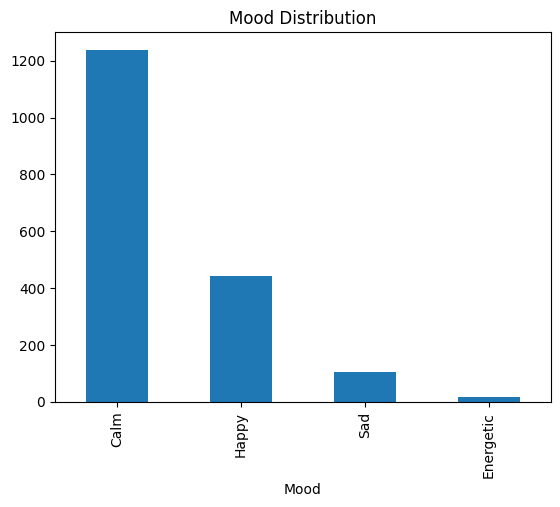

In [19]:
df["Mood"].value_counts().plot(kind="bar", title="Mood Distribution")


**Save processed dataset**

In [20]:
df.to_csv("deam_with_moods.csv", index=False)


**Valence–Arousal scatter**

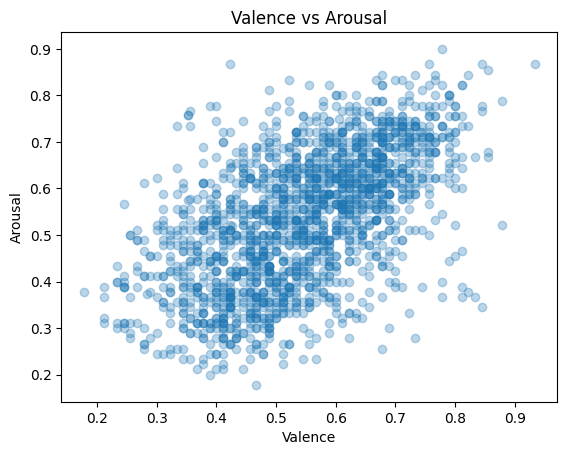

In [21]:
import matplotlib.pyplot as plt

plt.scatter(df["valence_norm"], df["arousal_norm"], alpha=0.3)
plt.xlabel("Valence")
plt.ylabel("Arousal")
plt.title("Valence vs Arousal")
plt.show()
